In [1]:
%env JAX_PLATFORM=cpu
%env CUDA_VISIBLE_DEVICES=-1

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

try:
    print(jax.devices())
except:
    print(jax.devices())

env: JAX_PLATFORM=cpu
env: CUDA_VISIBLE_DEVICES=-1
[CpuDevice(id=0)]


2024-10-10 09:08:08.092244: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [2]:
def track(t, track_name: str):
    t = jnp.clip(t, 0.0, 1.0)
    if track_name == "circle":
        x = 0.5 * jnp.cos(2 * jnp.pi * t) + 0.5
        y = 0.5 * jnp.sin(2 * jnp.pi * t)
    elif track_name == "square":
        cond = [t <= 0.25, t <= 0.5, t <= 0.75, t <= 1.0]
        x = jnp.select(cond, [4 * t, 1 + 0 * t, 3 - 4 * t, 0 * t])
        y = jnp.select(cond, [0 * t, 4 * t - 1.0, 1 + 0 * t, 4 - 4 * t])
    elif track_name == "mixed":
        cond = [t <= 0.25, t <= 0.75, t <= 1.0]
        x = jnp.select(cond, [4 * t, jnp.sin(jnp.pi * (t + 0.25)), 0 * t])
        y = jnp.select(cond, [0 * t, -jnp.cos(jnp.pi * (t + 0.25)), 4 - 4 * t])
    else:
        raise ValueError(f"unknown track name: {track_name}")
    return jnp.stack([x, y], axis=-1)

(5,) (1000, 2) (1000, 2)


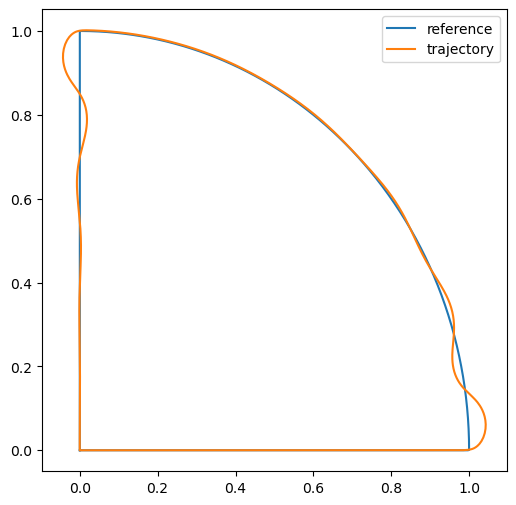

In [3]:
from systems import DSSM, Car
import equinox as eqx


class MPC(eqx.Module):
    system: DSSM
    Q: jax.Array
    R: jax.Array
    horizon: int

    def linearize(self, x0, u0=None):
        if u0 is None:
            u0 = jnp.zeros(self.system.u_dim)
        A = jax.jacobian(self.system.step, argnums=0)(x0, u0)
        B = jax.jacobian(self.system.step, argnums=1)(x0, u0)
        C = jax.jacobian(self.system.measure, argnums=0)(x0)
        d = self.system.step(x0, u0) - A @ x0 - B @ u0
        return A, B, C, d

    def condense(self, A, B, C, Q, R):
        def scan_fn(carry, _):
            Ac, Bc, Mc = carry
            Mc = Ac
            # if time dependent disturbances, use this instead
            # Mc = jnp.roll(Mc, shift=x_dim, axis=1)
            # Mc = Mc.at[:, :x_dim].set(Ac)
            Bc = jnp.roll(Bc, shift=self.system.u_dim, axis=1)
            Bc = Bc.at[:, : self.system.u_dim].set(Ac @ B)
            Ac = Ac @ A
            carry = (Ac, Bc, Mc)
            return carry, carry

        Ac0 = C
        Bc0 = jnp.zeros((self.system.y_dim, self.horizon * self.system.u_dim))
        Mc0 = jnp.zeros((self.system.y_dim, self.system.x_dim))
        _, (Ac, Bc, Mc) = jax.lax.scan(
            scan_fn, (Ac0, Bc0, Mc0), xs=None, length=self.horizon
        )
        Ac, Bc, Mc = jnp.concat(Ac), jnp.concat(Bc), jnp.concat(Mc)  # type: ignore
        Qc, Rc = jnp.kron(jnp.eye(self.horizon), Q), jnp.kron(jnp.eye(self.horizon), R)
        return Ac, Bc, Mc, Qc, Rc

    def optimize(self, x, y_ref, u0=None, Q=None, R=None):
        assert len(y_ref) == self.horizon
        A, B, C, d = self.linearize(x, u0)
        Q = Q or self.Q
        R = R or self.R
        Ac, Bc, Mc, Qc, Rc = self.condense(A, B, C, Q, R)
        y_ref = y_ref.flatten()
        U = jnp.linalg.solve(
            Bc.T @ Qc @ Bc + Rc,
            Bc.T @ Qc @ (y_ref - Ac @ x - Mc @ d),
        )
        return U[: self.system.u_dim]

    @eqx.filter_jit
    def follow(self, yt, x0=None):
        def scan_fn(x, y_ref):
            u = self.optimize(x, y_ref)
            x = self.system.step(x, u)
            y = self.system.measure(x)
            return x, (u, y)

        x = x0 or self.system.init_state()
        yt_pad = jnp.pad(yt, ((0, self.horizon), (0, 0)), mode="edge")
        y_ref = jnp.stack([yt_pad[i : i + self.horizon] for i in range(len(yt))])
        xf, (ut, yt) = jax.lax.scan(scan_fn, x, y_ref)
        return xf, ut, yt


car = Car()
mpc = MPC(system=car, Q=jnp.eye(2), R=jnp.eye(2) * 0.1, horizon=10)

y_ref = track(jnp.linspace(0, 1, 1000), "mixed")
xf, ut, yt = mpc.follow(y_ref)
print(xf.shape, ut.shape, yt.shape)

plt.figure(figsize=(6, 6))
plt.plot(y_ref[:, 0], y_ref[:, 1], label="reference")
plt.plot(yt[:, 0], yt[:, 1], label="trajectory")
plt.legend()

2 10 4
(10,) (1000, 2) (1000, 4)


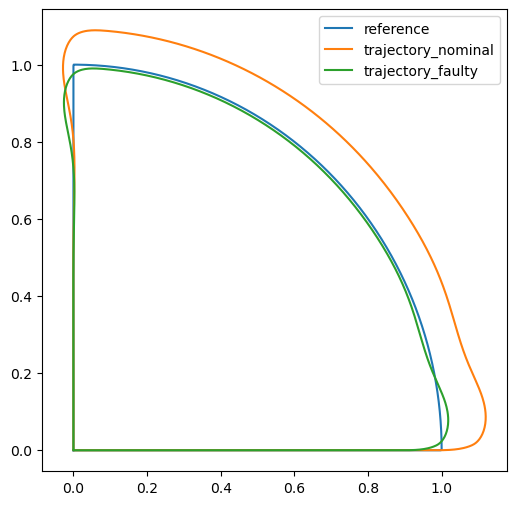

In [12]:
from typing import ClassVar


def merge(nominal, faulty):
    class MergedSystem(DSSM):
        x_dim: ClassVar[int] = nominal.x_dim + faulty.x_dim
        u_dim: ClassVar[int] = nominal.u_dim
        y_dim: ClassVar[int] = nominal.y_dim + faulty.y_dim

        def init_state(self, *, key=None):
            x_nominal = nominal.init_state(key=key)
            x_faulty = faulty.init_state(key=key)
            return jnp.concatenate([x_nominal, x_faulty], axis=-1)

        def step(self, x, u, *, key=None):
            x_nominal, x_faulty = jnp.split(x, 2, axis=-1)
            x_nominal = nominal.step(x_nominal, u, key=key)
            x_faulty = faulty.step(x_faulty, u, key=key)
            return jnp.concatenate([x_nominal, x_faulty], axis=-1)

        def measure(self, x, *, key=None):
            x_nominal, x_faulty = jnp.split(x, 2, axis=-1)
            y_nominal = nominal.measure(x_nominal, key=key)
            y_faulty = faulty.measure(x_faulty, key=key)
            return jnp.concatenate([y_nominal, y_faulty], axis=-1)

    return MergedSystem()


nominal = Car(mass=1.0)
faulty = Car(mass=1.1)
merged = merge(nominal, faulty)
print(merged.u_dim, merged.x_dim, merged.y_dim)


c = 10
Q = jnp.kron(jnp.array([[1 - c, c], [c, -c]]), jnp.eye(2))
mpc = MPC(system=merged, Q=Q, R=jnp.eye(2), horizon=30)

y_ref = track(jnp.linspace(0, 1, 1000), "mixed")
y_ref = jnp.concatenate([y_ref, y_ref], axis=-1)

xf, ut, yt = mpc.follow(y_ref)
print(xf.shape, ut.shape, yt.shape)

plt.figure(figsize=(6, 6))
plt.plot(y_ref[:, 0], y_ref[:, 1], label="reference")
plt.plot(yt[:, 0], yt[:, 1], label="trajectory_nominal")
plt.plot(yt[:, 2], yt[:, 3], label="trajectory_faulty")
plt.legend()

(10,) (1000, 2) (1000, 4)


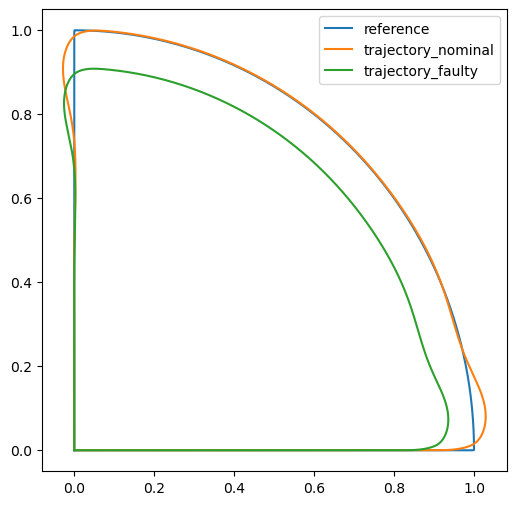

In [13]:
c = 0.01
Q = jnp.kron(jnp.array([[1 - c, c], [c, -c]]), jnp.eye(2))
mpc = MPC(system=merged, Q=Q, R=jnp.eye(2), horizon=30)

y_ref = track(jnp.linspace(0, 1, 1000), "mixed")
y_ref = jnp.concatenate([y_ref, y_ref], axis=-1)

xf, ut, yt = mpc.follow(y_ref)
print(xf.shape, ut.shape, yt.shape)

plt.figure(figsize=(6, 6))
plt.plot(y_ref[:, 0], y_ref[:, 1], label="reference")
plt.plot(yt[:, 0], yt[:, 1], label="trajectory_nominal")
plt.plot(yt[:, 2], yt[:, 3], label="trajectory_faulty")
plt.legend()